In [43]:
import numpy as np
import pandas as pd
import networkx as nx
import sys
sys.path.append(os.path.abspath("../src/"))

import os
import pickle
import utils as utils
import torch
import matplotlib.pyplot as plt
np.random.seed(1)

In [44]:
def load_and_plot_graph(file_path, plot=False):
    # Load the graph
    with open(file_path, 'rb') as f:
        G = pickle.load(f)
    
    # Ensure the loaded object is a NetworkX graph
    if not isinstance(G, nx.Graph):
        raise TypeError("The loaded object is not a NetworkX graph.")
    
    if plot:
        # Plot the graph using a spring layout
        plt.figure(figsize=(10, 7))
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True, node_color='lightblue', font_weight='bold', node_size=700, font_size=12)
        plt.title('Graph')
        plt.show()
    return G

In [20]:
model  = 'erdos_renyi'
number_of_nodes = 20
prob = 0.7
simulation_number = 0
DATA_PATH = '../src/data'
file_extension = 'pkl'

graph_file_path = f'{DATA_PATH}/inputs/{model}/graph_info_{number_of_nodes}_{prob}_sim_{simulation_number}.{file_extension}'
G = load_and_plot_graph(graph_file_path)


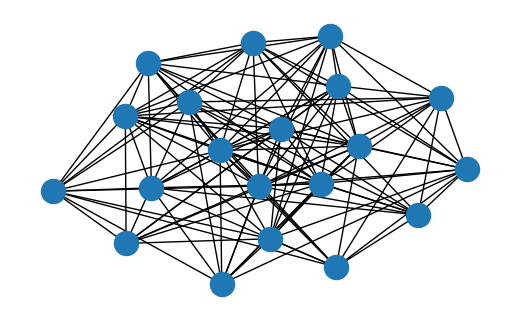

In [45]:
plt.figure(figsize=(5, 3))
nx.draw(G)

# Example with SAE embeddings

In [25]:
import networkx as nx

adjacency_matrix = nx.adjacency_matrix(G)
adjacency_matrix = np.array(adjacency_matrix.todense())
print("Adjacency Matrix:")
print(adjacency_matrix)


Adjacency Matrix:
[[0 0 0 1 0 1 0 1 0 1 0 0 1 1 1 1 1 1 0 0]
 [0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 1]
 [0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 0 1 0]
 [1 1 0 0 1 1 0 0 1 0 0 1 0 0 1 1 0 1 1 0]
 [0 1 1 1 0 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1]
 [1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0]
 [0 1 1 0 0 1 0 1 1 0 1 0 0 0 1 1 1 1 1 1]
 [1 1 0 0 0 1 1 0 1 1 0 1 1 0 1 1 1 1 1 1]
 [0 0 1 1 0 1 1 1 0 0 1 0 0 1 1 1 0 1 0 1]
 [1 1 0 0 0 1 0 1 0 0 1 1 0 0 0 1 0 1 1 0]
 [0 1 0 0 1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 1]
 [0 0 1 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1]
 [1 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 1 1]
 [1 1 1 0 1 1 0 0 1 0 0 0 1 0 1 0 1 1 0 0]
 [1 1 1 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1]
 [1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0]
 [1 1 0 0 1 1 1 1 0 0 1 0 0 1 1 1 0 0 1 1]
 [1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 0 1 1]
 [0 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 1]
 [0 1 0 0 1 0 1 1 1 0 1 1 1 0 1 0 1 1 1 0]]


In [26]:
import numpy as np

degree_dict = dict(G.degree())
n = len(degree_dict)
degree_matrix = np.zeros((n, n), dtype=int)
np.fill_diagonal(degree_matrix, list(degree_dict.values()))
print(degree_matrix)


[[10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 12  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 12  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 10  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 17  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 11  0  0

In [27]:
degree_matrix_inv = np.linalg.inv(degree_matrix + np.eye(degree_matrix.shape[0])) - np.eye(degree_matrix.shape[0])
embedding_input = np.matmul(degree_matrix_inv, adjacency_matrix)
embedding_input 

array([[ 0.        ,  0.        ,  0.        , -0.90909091,  0.        ,
        -0.90909091,  0.        , -0.90909091,  0.        , -0.90909091,
         0.        ,  0.        , -0.90909091, -0.90909091, -0.90909091,
        -0.90909091, -0.90909091, -0.90909091,  0.        ,  0.        ],
       [ 0.        ,  0.        , -0.9375    , -0.9375    , -0.9375    ,
        -0.9375    , -0.9375    , -0.9375    ,  0.        , -0.9375    ,
        -0.9375    ,  0.        , -0.9375    , -0.9375    , -0.9375    ,
        -0.9375    , -0.9375    ,  0.        , -0.9375    , -0.9375    ],
       [ 0.        , -0.90909091,  0.        ,  0.        , -0.90909091,
         0.        , -0.90909091,  0.        , -0.90909091,  0.        ,
         0.        , -0.90909091, -0.90909091, -0.90909091, -0.90909091,
        -0.90909091,  0.        ,  0.        , -0.90909091,  0.        ],
       [-0.90909091, -0.90909091,  0.        ,  0.        , -0.90909091,
        -0.90909091,  0.        ,  0.        , -

In [29]:
from models import SAE
model_emb = SAE.GraphModel

In [31]:
import torch
n = degree_matrix.shape[0]  # Number of nodes in your graph
hidden_size_1 = 5  # Size of the first hidden layer
hidden_size_2 = 2  # Size of the second hidden layer

#S = torch.rand(n, n)  # Example similarity matrix
#D = torch.diag(torch.sum(S, dim=1))  # Degree matrix
D = torch.from_numpy(degree_matrix).float()
S = torch.from_numpy(adjacency_matrix).float()

layers_sizes = [n, hidden_size_1, hidden_size_2]  # Define the sizes of your layers
rho = 0.05  # Sparsity parameter
beta = 1  # Weight for sparsity penalty
learning_rate = 0.01
num_epochs = 1000

# Ensure that D is invertible
D = D + torch.eye(n) * 1e-10

model = model_emb(S, D, layers_sizes, rho, beta, learning_rate, num_epochs)
hidden_activations = model()


In [32]:
print(len(hidden_activations))
print(hidden_activations[0].shape)
print(D.shape)

2
torch.Size([20, 5])
torch.Size([20, 20])


# Testing for multiple graphs

In [34]:
graph_file_path = DATA+'/outputs/erdos_renyi/'
graphs_list = os.listdir(graph_file_path)

graphs = list()
adj_graphs = list()
degrees = list()

# Hyperparameters
hidden_size_1 = 5  # Size of the first hidden layer
hidden_size_2 = 2  # Size of the second hidden layer
rho = 0.05  # Sparsity parameter
beta = 1  # Weight for sparsity penalty
learning_rate = 0.01
num_epochs = 1000
layers_sizes = [n, hidden_size_1, hidden_size_2]  # Define the sizes of your layers

for graph in graphs_list:
    G = load_and_plot_graph(graph_file_path+graph)
    graphs.append(G)

    adjacency_matrix = nx.adjacency_matrix(G)
    adjacency_matrix = np.array(adjacency_matrix.todense())
    adj_graphs.append(adjacency_matrix)

    degree_dict = dict(G.degree())
    n = len(degree_dict)
    degree_matrix = np.zeros((n, n), dtype=int)
    np.fill_diagonal(degree_matrix, list(degree_dict.values()))
    degrees.append(degree_matrix)


FileNotFoundError: [Errno 2] No such file or directory: '../src/data/outputs/erdos_renyi/'

In [ ]:
result = list()
for adjacency_matrix, degree_matrix in zip(adj_graphs, degrees):
    n = adjacency_matrix.shape[0]  # Number of nodes in your graph
    D = torch.from_numpy(degree_matrix).float()
    S = torch.from_numpy(adjacency_matrix).float()

    # Ensure that D is invertible
    D = D + torch.eye(n) * 1e-10

    model = model_emb(S, D, layers_sizes, rho, beta, learning_rate, num_epochs)
    hidden_activations = model()
    result.append(hidden_activations)
    #print('Result', hidden_activations)


# Spearman correlation of eigenvalues example usage

In [40]:
from models import Spectrum

In [42]:
# Example usage

# Assuming g1 and g2 are lists of adjacency matrices (numpy arrays)
# g1 = [adj_matrix1, adj_matrix2, ...]
# g2 = [adj_matrix1, adj_matrix2, ...]
# analysis = GraphSpectrumAnalysis()
# correlation = analysis.calculate_spearman_correlation(g1, g2)
# print("Spearman Correlation:", correlation)


<module 'models.Spectrum' from '/Users/maruanottoni/home/graph-corr-embedd/src/models/Spectrum.py'>